Newest should work

In [1]:
import pandas as pd

df = pd.read_csv("wm811K_csv_export.csv")

print(df.head())
print(df.info())

                                            waferMap  dieSize lotName  \
0  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
1  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
2  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
3  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
4  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   

   waferIndex  trianTestLabel failureType  
0         1.0  [['Training']]  [['none']]  
1         2.0  [['Training']]  [['none']]  
2         3.0  [['Training']]  [['none']]  
3         4.0  [['Training']]  [['none']]  
4         5.0  [['Training']]  [['none']]  
<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  str    
 1   dieSize         811457 non-null  float64
 2   lotName  

In [2]:
import numpy as np
import re

def parse_wafer_map(text):

    # extract rows between brackets
    rows = re.findall(r'\[([0-9\s]+)\]', text)

    wafer = []

    for r in rows:
        numbers = [int(x) for x in r.split()]
        wafer.append(numbers)

    return np.array(wafer)

In [3]:
df["waferMap"] = df["waferMap"].apply(parse_wafer_map)

In [4]:
print(type(df["waferMap"][0]))
print(df["waferMap"][0].shape)
print(df["waferMap"][0])

<class 'numpy.ndarray'>
(0,)
[]


In [5]:
df["failureType"] = df["failureType"].str.replace(r"[\[\]']", "", regex=True)
df["trianTestLabel"] = df["trianTestLabel"].str.replace(r"[\[\]']", "", regex=True)

In [6]:
print(df["failureType"].value_counts())

failureType
             638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [13]:
from skimage.transform import resize
def valid_map(w):
    w = np.array(w)
    return w.ndim == 2 and w.shape[0] > 0 and w.shape[1] > 0

df = df[df["waferMap"].apply(valid_map)]
def standardize_wafer(w, target_size=26):

    w = np.array(w)

    # remove NaN values if they exist
    w = np.nan_to_num(w)

    # ensure it is 2D
    if w.ndim != 2:
        return None

    h, w_ = w.shape

    new = np.zeros((target_size, target_size))

    h_min = min(h, target_size)
    w_min = min(w_, target_size)

    new[:h_min, :w_min] = w[:h_min, :w_min]

    return new
df["waferMap"] = df["waferMap"].apply(standardize_wafer)


In [14]:
X = np.stack(df["waferMap"].values)
y = df["failureType"].values

print(X.shape)

(299633, 26, 26)


In [15]:
print(X.shape)
print(y.shape)

(299633, 26, 26)
(299633,)


In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [20]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [21]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

rf.fit(X_train_flat, y_train)

pred = rf.predict(X_test_flat)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.98      0.87     45114
           1       0.29      0.00      0.01       545
           2       0.00      0.00      0.00         4
           3       0.54      0.04      0.08       325
           4       0.00      0.00      0.00        96
           5       0.25      0.03      0.06       212
           6       1.00      0.12      0.22        16
           7       0.50      0.05      0.09        43
           8       0.45      0.08      0.14        59
           9       0.75      0.16      0.27     13513

    accuracy                           0.78     59927
   macro avg       0.46      0.15      0.17     59927
weighted avg       0.76      0.78      0.72     59927



x:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(26,26,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

x:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7602 - loss: 0.6581 - val_accuracy: 0.7663 - val_loss: 0.6379
Epoch 2/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7653 - loss: 0.6437 - val_accuracy: 0.7678 - val_loss: 0.6347
Epoch 3/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7671 - loss: 0.6390 - val_accuracy: 0.7619 - val_loss: 0.6399
Epoch 4/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7688 - loss: 0.6358 - val_accuracy: 0.7682 - val_loss: 0.6371
Epoch 5/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7704 - loss: 0.6320 - val_accuracy: 0.7678 - val_loss: 0.6327
Epoch 6/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7716 - loss: 0.6290 - val_accuracy: 0.7692 - val_loss: 0.6339
Epoch 7/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7737 - loss: 0.6256 - val_accuracy: 0.7694 - val_loss: 0.6334
Epoch 8/10
2997/2997 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7755 - loss: 0

In [26]:
pred = model.predict(X_test)
pred = pred.argmax(axis=1)

1873/1873 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


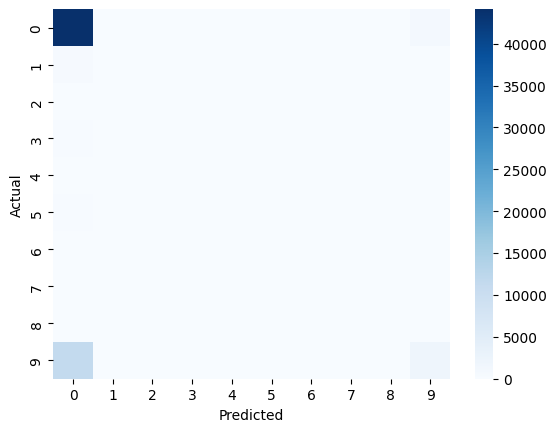

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()